# Relatório de Performance

**Repositório:** https://github.com/FigLucas/Simulador-de-e-Livro-de-Ofertas-e-Performance-de-Estruturas

## Objetivo

Este notebook analisa o desempenho do código feito no projeto. A análise se dá por meio da:

- **Análise teórica**: olhando o custo das operações
- **Análise empírica**: medindo tempos para volumes e tipos diferentes de ordens

# 1. Importação das classes do projeto

In [21]:
from pathlib import Path
import sys
import time
import random
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
    "figure.figsize": (10, 6),
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "grid.alpha": 0.7
})

if Path.cwd().name == "notebook":
    path_p = Path.cwd().parent
else:
    path_p = Path.cwd()

if str(path_p) not in sys.path:
    sys.path.append(str(path_p))

from src.order import Ordem
from src.queue import Fila
from src.stack import Pilha
from src.order_book import LivroOfertas, MotorNegociacao
from src.simulator import Simulador

print("Importações realizadas!")

Importações realizadas!


# 2. Estruturas usadas

O código usa as seguintes estruturas:

## Fila

A classe `Fila` guarda as ordens antes de elas entrarem no livro. Ela segue a regra FIFO, onde a primeira ordem inserida é a primeira removida. Como a fila guarda referência para o início e para o fim, inserir no fim e remover do início custam $O(1)$.

## Pilha

A classe `Pilha` é usada para o undo. Ela segue a regra LIFO, então o último ID inserido é o primeiro removido. Como tudo acontece no topo, as operações principais custam $O(1)$.

## Livro de Ofertas

A classe `LivroOfertas` possui duas listas duplamente encadeadas:

- `compras`: ordenada por maior preço primeiro;
- `vendas`: ordenada por menor preço primeiro.

A inserção no livro chama `inserir_ordem`. Esse método verifica se a ordem já existe e depois coloca a ordem na lista correta. Como a lista encadeada precisa ser percorrida nó por nó, a busca e a inserção ordenada podem custar $O(n)$.

Além disso, o motor usa `RegistroIds` para guardar os IDs já recebidos. Como esse registro também é uma lista encadeada simples, o método `RegistroIds.contem` faz uma busca sequencial antes de colocar uma nova ordem na fila. Portanto, a validação de duplicidade aparece em dois momentos do fluxo completo: primeiro no motor, por `RegistroIds.contem`, e depois no livro, por `LivroOfertas.ordem_existe`.

# 3. Complexidade teórica

| Parte do código | Operação | Complexidade |
|---|---|---:|
| `Fila.insere` | inserir no fim da fila | $O(1)$ |
| `Fila.remove` | remover do início da fila | $O(1)$ |
| `Pilha.empilha` | inserir no topo | $O(1)$ |
| `Pilha.desempilha` | remover do topo | $O(1)$ |
| `RegistroIds.contem` | verificar se um ID já foi recebido | $O(n)$ |
| `RegistroIds.adicionar` | registrar um novo ID no fim da lista | $O(1)$ |
| `LivroOfertas.ordem_existe` | procurar uma ordem pelo ID | $O(n)$ |
| `LivroOfertas.inserir_ordem` | inserir na lista de compras ou vendas | $O(n)$ |
| `LivroOfertas.remover_ordem_por_id` | procurar e remover pelo ID | $O(n)$ |
| `LivroOfertas.obter_melhor_compra` | acessar o primeiro nó de compras | $O(1)$ |
| `LivroOfertas.obter_melhor_venda` | acessar o primeiro nó de vendas | $O(1)$ |

Se há n ordens no livro, uma busca em lista encadeada pode precisar olhar até n nós. Quando processamos muitas ordens, esse custo vai se repetindo. No pior caso, a soma dos percursos fica parecida com:

$$1 + 2 + 3 + \cdots + (n-1) = \frac{n(n-1)}{2}$$

Assim, o custo esperado para o fluxo completo fica próximo de $O(n^2)$. Esse crescimento não vem de uma única operação isolada, mas da repetição de várias buscas lineares: a verificação de ID em `RegistroIds`, a verificação de existência no `LivroOfertas` e a própria inserção ordenada nas listas de compra e venda.

# 4. Teste do Simulador

A classe `Simulador`, cria ordens aleatórias para testar o sistema. Primeiro vamos medir apenas o tempo para gerar ordens.

In [22]:
simulador = Simulador()

quantidades = [1000, 2000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
resultados_geracao = []

for quantidade in quantidades:
    random.seed(42)
    tempo = simulador.medir_tempo_execucao(lambda quantidade=quantidade: simulador.gerar_ordens(quantidade))

    resultados_geracao.append({
        "quantidade": quantidade,
        "tempo": tempo
    })

try:
    import pandas as pd
    display(pd.DataFrame(resultados_geracao))
except ImportError:
    for resultado in resultados_geracao:
        print(resultado)

,quantidade,tempo
0,1000,0.001494
1,2000,0.002991
2,4000,0.006216
3,5000,0.006705
4,6000,0.007573
5,7000,0.009703
6,8000,0.011220
7,9000,0.013218
8,10000,0.015478


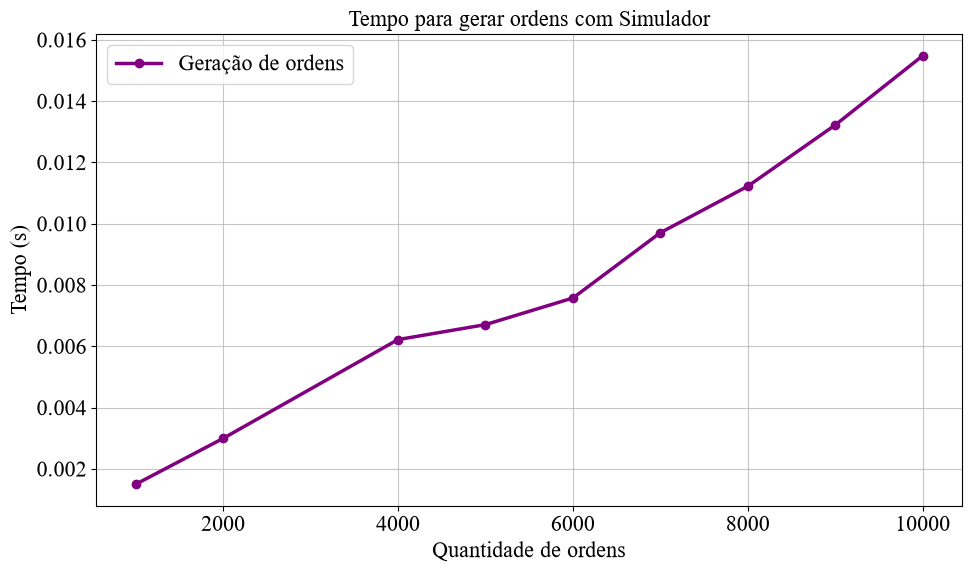

In [23]:
x = []
y = []

for resultado in resultados_geracao:
    x.append(resultado["quantidade"])
    y.append(resultado["tempo"])

plt.figure()
plt.plot(x, y, marker="o", linewidth=2.5, color="purple", label="Geração de ordens")
plt.title("Tempo para gerar ordens com Simulador")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Análise do gráfico de geração de ordens

O gráfico mostra o tempo necessário apenas para criar as ordens simuladas. Como o eixo horizontal representa a quantidade de ordens e o eixo vertical representa o tempo de geração, a principal análise é que o aumento do tempo acompanha o aumento do volume de dados, mas sem ser de forma muito acelerada.

Esse comportamento é coerente com a forma como o `Simulador.gerar_ordens` funciona. Para cada repetição, o simulador cria uma nova instância de `Ordem`, preenchendo informações como ID, tipo, preço, quantidade e timestamp. Não há, nessa etapa, busca em lista encadeada, inserção ordenada no livro de ofertas ou remoção de elementos. Por isso, o custo esperado é próximo de linear, ou seja, a geração de ordens é uma etapa relativamente barata quando comparada com o processamento completo do sistema.

# 5. Análise empírica do fluxo completo

Agora o teste mede o fluxo completo:

1. gerar ordens com `Simulador.gerar_ordens`;
2. criar uma `Fila`;
3. criar um `LivroOfertas`;
4. criar uma `Pilha`;
5. criar o `MotorNegociacao`;
6. receber as ordens com `receber_nova_ordem`;
7. processar tudo com `processar_fila_para_o_livro`.

Este é o teste principal, pois usa o código do projeto como ele foi feito.

In [24]:
quantidades = [1000, 2000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
resultados_fluxo = []

for quantidade in quantidades:
    random.seed(42)
    ordens = simulador.gerar_ordens(quantidade)

    fila_entrada = Fila()
    livro_ofertas = LivroOfertas()
    pilha_undo = Pilha()
    motor = MotorNegociacao(fila_entrada, livro_ofertas, pilha_undo, verbose=False)

    inicio = time.time()

    for ordem in ordens:
        motor.receber_nova_ordem(ordem)

    motor.processar_fila_para_o_livro()

    fim = time.time()

    resultados_fluxo.append({
        "quantidade": quantidade,
        "tempo": fim - inicio,
        "compras_restantes": livro_ofertas.compras.size,
        "vendas_restantes": livro_ofertas.vendas.size,
        "total_restante": livro_ofertas.total_ordens()
    })

try:
    display(pd.DataFrame(resultados_fluxo))
except NameError:
    for resultado in resultados_fluxo:
        print(resultado)

,quantidade,tempo,compras_restantes,vendas_restantes,total_restante
0,1000,0.018999,104,139,243
1,2000,0.065687,235,256,491
2,4000,0.223578,488,479,967
3,5000,0.438792,570,610,1180
4,6000,0.571284,691,700,1391
5,7000,0.744964,842,795,1637
6,8000,1.143260,923,911,1834
7,9000,1.759959,1037,1038,2075
8,10000,2.112511,1130,1149,2279


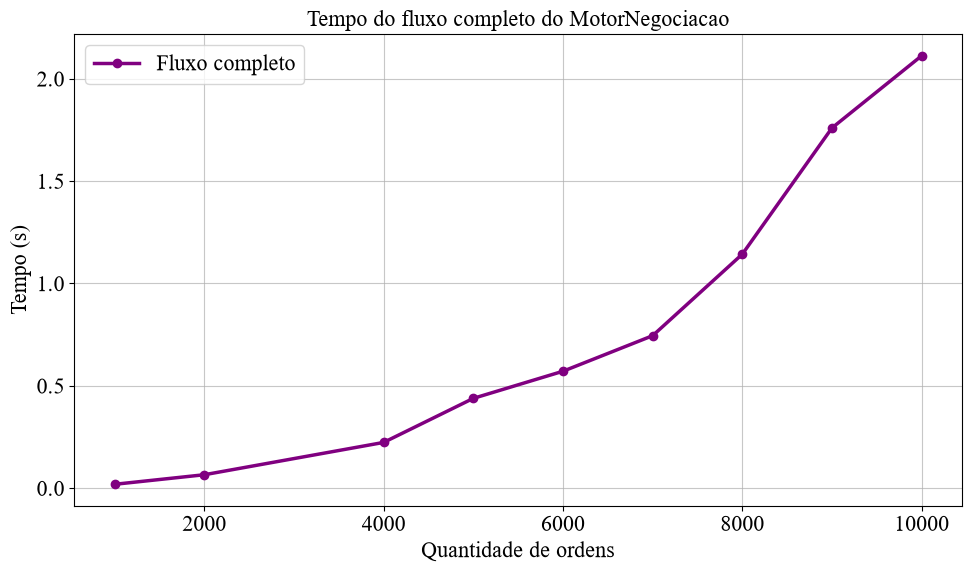

In [25]:
x = []
y = []

for resultado in resultados_fluxo:
    x.append(resultado["quantidade"])
    y.append(resultado["tempo"])

plt.figure()
plt.plot(x, y, marker="o", linewidth=2.5, color="purple", label="Fluxo completo")
plt.title("Tempo do fluxo completo do MotorNegociacao")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Análise do gráfico do fluxo completo

Neste gráfico, o crescimento do tempo é mais acentuado do que no teste de geração de ordens. Isso indica que o custo principal do projeto não está em criar os objetos `Ordem`, mas sim em processá-los dentro do fluxo do `MotorNegociacao` e do `LivroOfertas`.

O fluxo completo envolve várias operações encadeadas: recebimento da ordem, verificação de ID repetido, inserção na fila, processamento da fila, tentativa de inserção no livro, registro na pilha de undo e verificação de possíveis negociações. Embora a `Fila` e a `Pilha` tenham operações principais de custo constante, o livro de ofertas depende de listas duplamente encadeadas ordenadas. Assim, conforme a quantidade de ordens aumenta, cada nova ordem pode exigir percursos maiores para validar sua existência e encontrar sua posição correta.

A inclinação crescente da curva sugere um comportamento acumulativo: o sistema não executa apenas uma operação de custo O(n), mas repete operações lineares para muitas ordens. Dessa forma, o custo total tende a se aproximar de um crescimento quadrático. Esse resultado reforça a análise teórica apresentada antes, em que as buscas e inserções ordenadas no `LivroOfertas` aparecem como os pontos de maior impacto no desempenho.

# 6. Comparação entre melhor caso e pior caso de inserção

## Melhor caso

Foram criadas ordens de compra com preço crescente. Como a lista de compras coloca o maior preço no início, cada nova ordem tende a entrar no começo.

## Pior caso

Foram criadas ordens de compra com preço decrescente. Nesse caso, cada nova ordem tende a entrar no final da lista, então a lista precisa ser percorrida por mais tempo.

In [26]:
quantidades = [1000, 2000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
resultados_casos = []

for quantidade in quantidades:
    ordens = Fila()
    for i in range(quantidade):
        ordem = Ordem(i, "C", i + 1, 1, i)
        ordens.insere(ordem)

    fila_entrada = Fila()
    livro_ofertas = LivroOfertas()
    pilha_undo = Pilha()
    motor = MotorNegociacao(fila_entrada, livro_ofertas, pilha_undo, verbose=False)

    inicio = time.time()
    for ordem in ordens:
        motor.receber_nova_ordem(ordem)
    motor.processar_fila_para_o_livro()
    fim = time.time()

    resultados_casos.append({
        "quantidade": quantidade,
        "caso": "melhor_posicao",
        "tempo": fim - inicio
    })

    ordens = Fila()
    for i in range(quantidade):
        ordem = Ordem(i, "C", quantidade - i, 1, i)
        ordens.insere(ordem)

    fila_entrada = Fila()
    livro_ofertas = LivroOfertas()
    pilha_undo = Pilha()
    motor = MotorNegociacao(fila_entrada, livro_ofertas, pilha_undo, verbose=False)

    inicio = time.time()
    for ordem in ordens:
        motor.receber_nova_ordem(ordem)
    motor.processar_fila_para_o_livro()
    fim = time.time()

    resultados_casos.append({
        "quantidade": quantidade,
        "caso": "pior_posicao",
        "tempo": fim - inicio
    })

try:
    display(pd.DataFrame(resultados_casos))
except NameError:
    for resultado in resultados_casos:
        print(resultado)

,quantidade,caso,tempo
0,1000,melhor_posicao,0.028805
1,1000,pior_posicao,0.062159
2,2000,melhor_posicao,0.116653
3,2000,pior_posicao,0.271214
4,4000,melhor_posicao,0.554795
5,4000,pior_posicao,1.341409
6,5000,melhor_posicao,0.747552
7,5000,pior_posicao,1.753772
8,6000,melhor_posicao,1.086056
9,6000,pior_posicao,3.165409


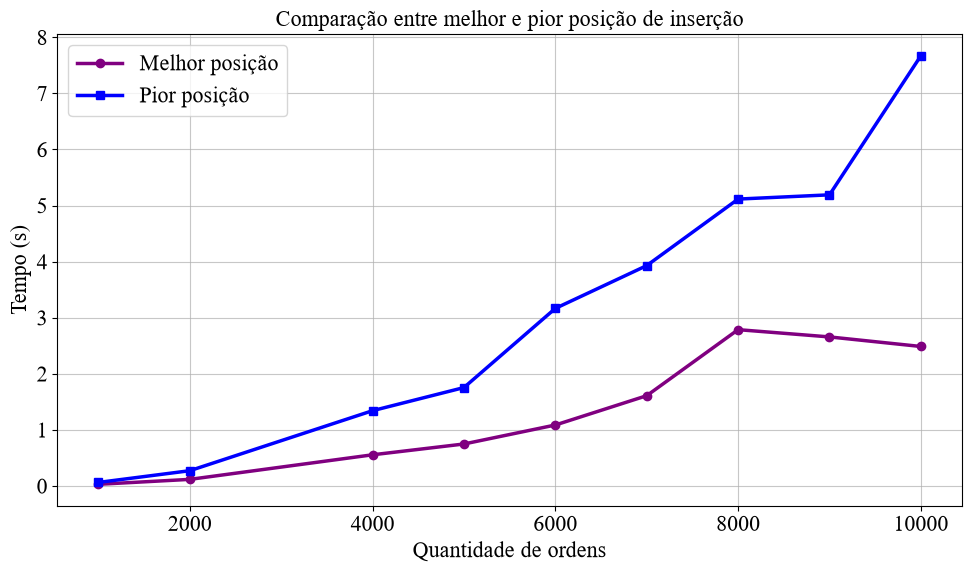

In [27]:
x_melhor = []
y_melhor = []
x_pior = []
y_pior = []

for resultado in resultados_casos:
    if resultado["caso"] == "melhor_posicao":
        x_melhor.append(resultado["quantidade"])
        y_melhor.append(resultado["tempo"])
    else:
        x_pior.append(resultado["quantidade"])
        y_pior.append(resultado["tempo"])

plt.figure()
plt.plot(x_melhor, y_melhor, marker="o", linewidth=2.5, color="purple", label="Melhor posição")
plt.plot(x_pior, y_pior, marker="s", linewidth=2.5, color="blue", label="Pior posição")
plt.title("Comparação entre melhor e pior posição de inserção")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Análise da comparação entre melhor e pior posição

A comparação evidencia como a posição de inserção dentro da lista encadeada influencia diretamente o tempo de execução. No melhor caso, as ordens de compra foram construídas de modo que cada nova ordem tivesse prioridade maior e, portanto, fosse inserida perto do início da lista. Isso reduz o percurso necessário para localizar a posição de inserção.

No pior caso, ocorre o contrário: as ordens tendem a ser inseridas no final da lista de compras. Como a estrutura é encadeada, não há acesso direto a uma posição intermediária ou final. O algoritmo precisa passar nó por nó até encontrar o ponto correto, fazendo com que o tempo cresça mais rapidamente à medida que a quantidade de ordens aumenta.

Um ponto importante é que o melhor caso não elimina completamente o crescimento do tempo. Mesmo quando a posição de inserção é encontrada rapidamente, o fluxo ainda realiza verificações lineares, como `RegistroIds.contem` e `LivroOfertas.ordem_existe`. Portanto, o gráfico mostra que a posição de inserção é relevante, mas não é o único fator que explica o custo total do processamento.

# 7. Teste com os matchs

Neste teste, metade das ordens é de compra e metade é de venda. Os preços são escolhidos para permitir o match de ordens.

Assim, além da inserção no livro, o método `processar_match` também trabalha removendo ordens executadas.

In [28]:
quantidades = [1000, 2000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
resultados_match = []

for quantidade in quantidades:
    ordens = Fila()
    metade = quantidade // 2

    for i in range(metade):
        ordem = Ordem(i, "C", 200.0, 1, i)
        ordens.insere(ordem)

    for i in range(metade, quantidade):
        ordem = Ordem(i, "V", 100.0, 1, i)
        ordens.insere(ordem)

    fila_entrada = Fila()
    livro_ofertas = LivroOfertas()
    pilha_undo = Pilha()
    motor = MotorNegociacao(fila_entrada, livro_ofertas, pilha_undo, verbose=False)

    inicio = time.time()
    for ordem in ordens:
        motor.receber_nova_ordem(ordem)
    motor.processar_fila_para_o_livro()
    fim = time.time()

    resultados_match.append({
        "quantidade": quantidade,
        "tempo": fim - inicio,
        "compras_restantes": livro_ofertas.compras.size,
        "vendas_restantes": livro_ofertas.vendas.size,
        "total_restante": livro_ofertas.total_ordens()
    })

try:
    display(pd.DataFrame(resultados_match))
except NameError:
    for resultado in resultados_match:
        print(resultado)

,quantidade,tempo,compras_restantes,vendas_restantes,total_restante
0,1000,0.031665,0,0,0
1,2000,0.132324,0,0,0
2,4000,0.506663,0,0,0
3,5000,0.816448,0,0,0
4,6000,1.259045,0,0,0
5,7000,1.635658,0,0,0
6,8000,2.265136,0,0,0
7,9000,2.753039,0,0,0
8,10000,3.373131,0,0,0


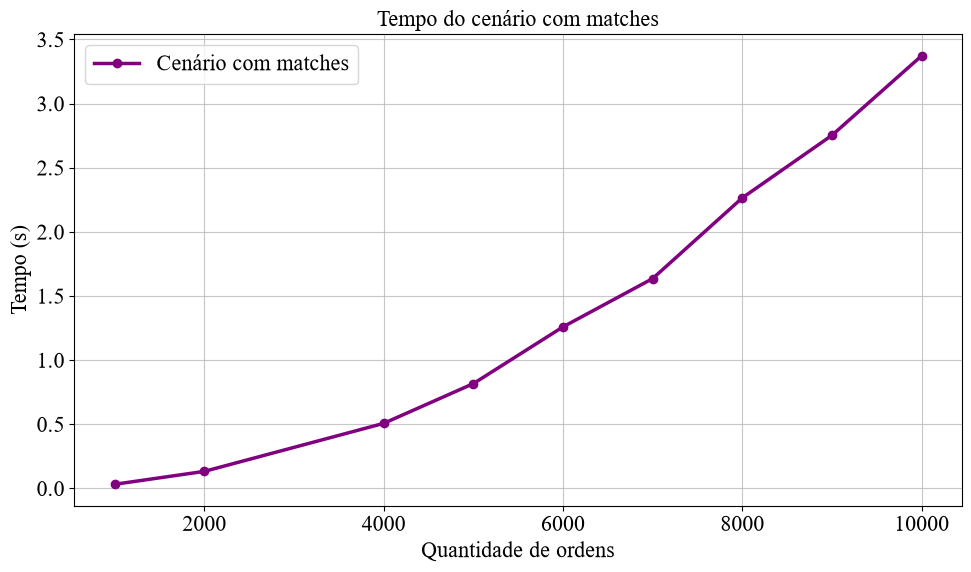

In [29]:
x = []
y = []

for resultado in resultados_match:
    if resultado["tempo"] > 0:
        x.append(resultado["quantidade"])
        y.append(resultado["tempo"])

plt.figure()
plt.plot(x, y, marker="o", linewidth=2.5, color="purple", label="Cenário com matches")

plt.title("Tempo do cenário com matches")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Análise do cenário com matchs

O gráfico do cenário com matchs mede uma situação mais próxima de um livro de ofertas em funcionamento, pois as ordens de compra e venda são compatíveis e podem gerar negociações. Nesse caso, o sistema não apenas recebe e insere ordens, mas também compara a melhor compra com a melhor venda e remove ordens que foram executadas.

A consulta à melhor compra e à melhor venda é eficiente, pois essas informações ficam no início das listas ordenadas. Entretanto, a execução de um match pode exigir atualização de quantidades e remoção de ordens concluídas. Como a remoção por ID depende de busca sequencial, essa etapa adiciona custo ao processamento.

Ao mesmo tempo, os matchs podem diminuir o número de ordens restantes no livro, o que reduz parcialmente o tamanho das listas que serão percorridas depois. Por isso, nesse cenário: há trabalho extra para negociar e remover ordens, mas também há redução do livro quando as ordens são executadas. A tendência crescente do gráfico mostra que, mesmo com essa redução, o aumento do volume de ordens ainda torna o processamento mais pesado.

# 8. Ajuste de uma curva quadrática O(n²)

In [30]:
x = []
y = []

for resultado in resultados_fluxo:
    x.append(resultado["quantidade"])
    y.append(resultado["tempo"])
x = np.array(x, dtype=float)
y = np.array(y, dtype=float)

# Ajuste polinomial de grau 2 por mínimos quadrados
coeficientes = np.polyfit(x, y, deg=2)
a = coeficientes[0]
b = coeficientes[1]
c = coeficientes[2]
modelo_quadratico = np.poly1d(coeficientes)
y_ajustado = modelo_quadratico(x)

#Cálculo do R quadrado
r2 = 1 - (np.sum((y - y_ajustado) ** 2) / np.sum((y - np.mean(y)) ** 2))

print(f"Modelo ajustado:")
print(f"T(n) = {a:.12e} * n² + {b:.12e} * n + {c:.12e}")
print(f"R² = {r2:.4f}")

Modelo ajustado:
T(n) = 3.132175284011e-08 * n² + -1.160340436964e-04 * n + 1.484248472720e-01
R² = 0.9891


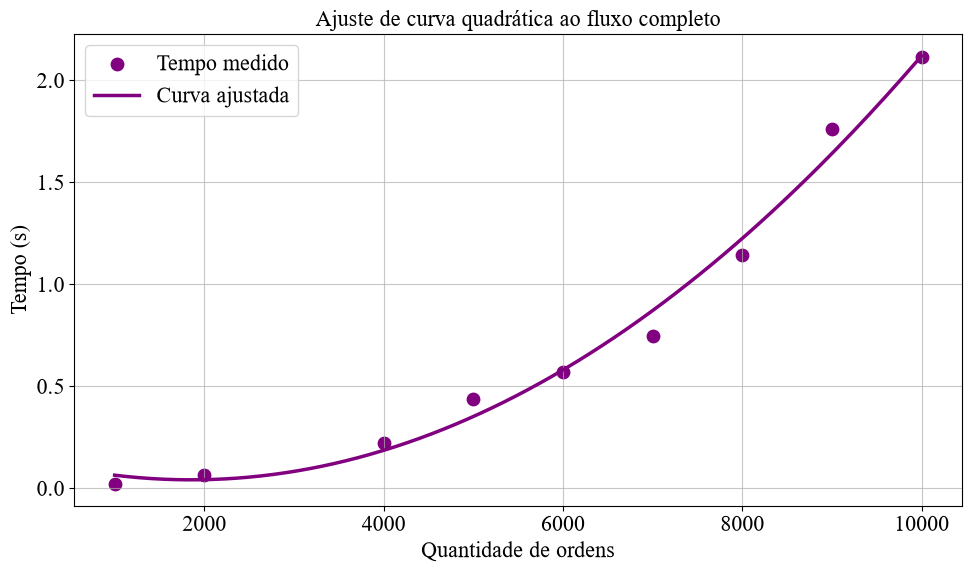

In [31]:
x_suave = np.linspace(x.min(), x.max(), 200)
y_suave = modelo_quadratico(x_suave)

plt.figure()
plt.scatter(x, y, color="purple", s=80, label="Tempo medido")
plt.plot(x_suave, y_suave, color="purple", linewidth=2.5, label="Curva ajustada")
plt.title(r"Ajuste de curva quadrática ao fluxo completo")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Análise do ajuste quadrático

O gráfico compara os tempos medidos no fluxo completo com uma curva quadrática ajustada por mínimos quadrados. Os pontos representam os valores empíricos obtidos nos testes, enquanto a linha mostra o comportamento previsto pelo modelo $T(n) = an^2 + bn + c$.

A proximidade entre os pontos e a curva indica que o modelo quadrático descreve bem a tendência observada. Isso confirma a medição prática com a análise teórica, quando operações O(n) são repetidas para um conjunto crescente de ordens, o custo acumulado pode se comportar como O(n²).

Esse ajuste não significa que cada operação individual do sistema seja quadrática. Na verdade, várias operações isoladas continuam sendo O(1), como inserir na fila, remover da fila, empilhar e acessar o melhor preço. O crescimento quadrático aparece no conjunto do fluxo, principalmente porque buscas, validações e inserções ordenadas em listas encadeadas são repetidas muitas vezes. Assim, o gráfico confirma que o peso no desempenho está nas operações lineares acumuladas dentro do `MotorNegociacao` e do `LivroOfertas`.

# 9. Conclusão

A partir dos testes realizados, é possível observar que as diferentes partes do sistema possuem custos bem diferentes. O primeiro teste mediu apenas a geração de ordens pelo `Simulador.gerar_ordens`. Nesse caso, o crescimento do tempo é relativamente baixo e próximo de linear, então essa etapa não representa o principal custo do projeto.

Em seguida, o teste do fluxo completo apresentou crescimento mais acentuado. Esse resultado é esperado, pois o fluxo completo inclui a entrada das ordens na fila, o processamento pelo `MotorNegociacao`, a inserção no `LivroOfertas`, o empilhamento do ID na pilha de undo e a verificação de possíveis matchs. Embora a fila e a pilha tenham operações principais de custo constante, o livro de ofertas usa listas duplamente encadeadas ordenadas. Dessa forma, cada nova ordem pode exigir um percurso sequencial pelos nós até encontrar a posição correta de inserção.

Além disso, a validação de IDs também pesa no fluxo, pois ocorre tanto em `MotorNegociacao.receber_nova_ordem`, com `RegistroIds.contem`, quanto em `LivroOfertas.inserir_ordem`, com `ordem_existe`. Como essas verificações são sequenciais, ainda há custo de busca mesmo quando a inserção acontece no início da lista. A comparação entre melhor e pior caso reforça isso: com preços crescentes, as compras tendem a entrar no início da lista; com preços decrescentes, tendem a entrar no final, exigindo a passagem por mais nós. Assim, o pior caso cresce mais rapidamente, mas o melhor caso também mantém custo relevante por causa das buscas auxiliares.

Já no cenário com matchs, o tempo também cresce de forma significativa. Nesse teste, foram criadas ordens de compra e venda compatíveis, de modo que o motor de negociação precisasse executar transações. A comparação entre a melhor compra e a melhor venda é rápida, pois ambas estão no início das listas. Porém, quando uma ordem é totalmente executada, o sistema precisa removê-la do livro. Como a remoção é feita por ID, ela depende novamente de uma busca sequencial. Assim, o cenário com matchs adiciona operações de atualização e remoção ao custo de inserção, tornando o processamento mais pesado.

Por fim, o ajuste de curva quadrática por mínimos quadrados confirmou a análise teórica. A curva ajustada ficou próxima dos pontos medidos no fluxo completo, indicando que o crescimento observado é compatível com uma tendência quadrática. Além disso, a comparação com outros modelos mostrou que o comportamento do fluxo completo é melhor explicado por uma curva de crescimento acelerado do que por uma curva linear simples.

Assim, esse resultado está de acordo com a análise assintótica feita anteriormente. Como operações de busca, inserção ordenada, validação de IDs e remoção por ID podem custar O(n), e essas operações são repetidas para muitas ordens, o custo acumulado tende a se aproximar de O(n²). Portanto, os gráficos confirmam empiricamente que o principal custo do sistema está nas operações sequenciais realizadas no motor de negociação e no `LivroOfertas`.